In [48]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]


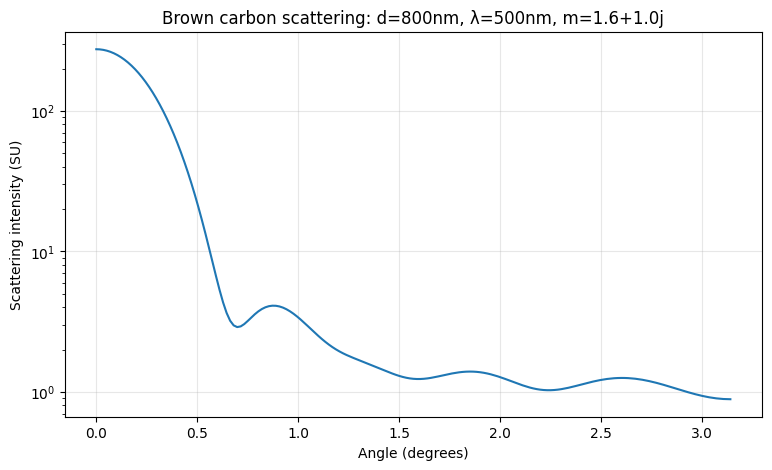

In [49]:
# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm

m = complex(n, k)
theta, SL, SR, SU = ps.ScatteringFunction(
    m, wavelength, diameter,
    minAngle=0, maxAngle=180, angularResolution=1
)

print("theta shape:", theta.shape)
print("SU shape:", SU.shape)
print("First few SU values:", SU[:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, SU)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
N_SAMPLES = 10000

# Pre-allocate arrays
inputs = np.zeros((N_SAMPLES, 4))     # 2 features: wavelength, diameter
outputs = np.zeros((N_SAMPLES, 181))  # 181 angles per curve

# Fixed values for brown carbon
# n = 1.6
# k = 1.0
# m = complex(n, k)

print("Generating training data through physics")

for i in range(N_SAMPLES):
    # Sample random wavelength and diameter
    wavelength = np.random.uniform(450, 550)
    diameter = np.random.uniform(700, 900)
    n = np.random.uniform(1.5, 1.86) # following the paper from Liu et al
    k = np.random.uniform(0.68, 1.00) # following the paper from Liu et al
    m = complex(n, k)
    
    # Run Mie calculation, we'll treat this as the accurate data
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    
    # Store inputs and outputs
    inputs[i] = [wavelength, diameter, n, k]
    outputs[i] = SU
    
    if i % 100 == 0:
        print(f"  {i}/{N_SAMPLES} done")

print("\nDone!")
print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)

Generating training data through physics
  0/10000 done
  100/10000 done
  200/10000 done
  300/10000 done
  400/10000 done
  500/10000 done
  600/10000 done
  700/10000 done
  800/10000 done
  900/10000 done
  1000/10000 done
  1100/10000 done
  1200/10000 done
  1300/10000 done
  1400/10000 done
  1500/10000 done
  1600/10000 done
  1700/10000 done
  1800/10000 done
  1900/10000 done
  2000/10000 done
  2100/10000 done
  2200/10000 done
  2300/10000 done
  2400/10000 done
  2500/10000 done
  2600/10000 done
  2700/10000 done
  2800/10000 done
  2900/10000 done
  3000/10000 done
  3100/10000 done
  3200/10000 done
  3300/10000 done
  3400/10000 done
  3500/10000 done
  3600/10000 done
  3700/10000 done
  3800/10000 done
  3900/10000 done
  4000/10000 done
  4100/10000 done
  4200/10000 done
  4300/10000 done
  4400/10000 done
  4500/10000 done
  4600/10000 done
  4700/10000 done
  4800/10000 done
  4900/10000 done
  5000/10000 done
  5100/10000 done
  5200/10000 done
  5300/10000 done

took 4 minutes and 20 seconds for mie theory calculations for 10000 samples

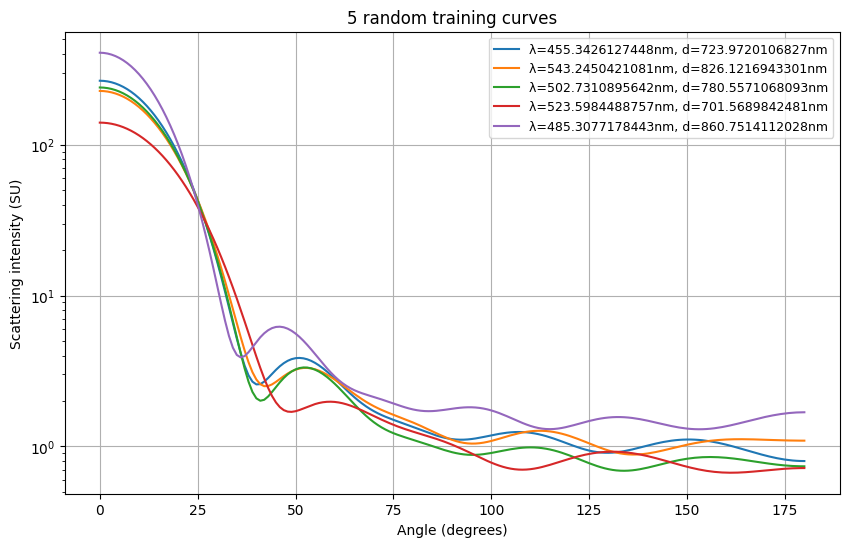

In [51]:
plt.figure(figsize=(10, 6))

# Plot 5 random curves
indices = np.random.choice(N_SAMPLES, 5, replace=False)

# generate lables for each line
for i in indices:
    label = f"λ={inputs[i,0]:.10f}nm, d={inputs[i,1]:.10f}nm"
    plt.plot(outputs[i], label=label)

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("5 random training curves")
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=1.0)
plt.show()

graphed 5 random training data points, just to see the shape of the results

In [52]:
# 1. Log-transform the outputs
log_outputs = np.log10(outputs)   # base-10 log

# 2. Normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 450) / 100   # wavelength
inputs_norm[:, 1] = (inputs[:, 1] - 700) / 200   # diameter
inputs_norm[:, 2] = (inputs[:, 2] - 1.5) / (1.86-1.5) # normalize n
inputs_norm[:, 3] = (inputs[:, 3] - 0.68) / (1.00-0.68) # normalize n

# 3. Train/test split — first 800 train, last 200 test
X_train = inputs_norm[:8000] # contains wavelength and diameter
y_train = log_outputs[:8000] # amount of light at each angle, values have had log applied
X_test = inputs_norm[8000:]
y_test = log_outputs[8000:]

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print()
print("Sample input (normalized):", X_train[0])

X_train shape: torch.Size([8000, 4])
y_train shape: torch.Size([8000, 181])
X_test shape: torch.Size([2000, 4])
y_test shape: torch.Size([2000, 181])

Sample input (normalized): tensor([0.3745, 0.9507, 0.7320, 0.5987])


Split the data into training and testing data, formatting the data so it's ready for training. Converting numpy arrays into Tensors.

In [53]:
model = nn.Sequential(
    nn.Linear(4, 128),       # input layer: 4 features to 128 neurons
    nn.GELU(),
    nn.Linear(128, 256),     # hidden layer: 128 to 256
    nn.GELU(),
    nn.Linear(256, 512),
    nn.GELU(),
    nn.Linear(512, 256),     # output layer: 256 to 256 (one per angle)
    nn.GELU(),
    nn.Linear(256, 181),    # ouput layer: 256 to 181
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=256, out_features=512, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=512, out_features=256, bias=True)
  (7): GELU(approximate='none')
  (8): Linear(in_features=256, out_features=181, bias=True)
)

Total parameters: 343093


building NN layers, applying ReLu between each. Printing the model and counting the number of parameters.

In [54]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [55]:
N_EPOCHS = 200
BATCH_SIZE = 128

train_losses = []
test_losses = []

n_train = X_train.shape[0]   # 800
n_batches = n_train // BATCH_SIZE  # 800 // 32 = 25

print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

import time

training_start = time.time()

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    
    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end] # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        
        # Standard 5-step training pattern
        pred = model(X_batch) # predict
        loss = loss_fn(pred, y_batch) # get the loss
        
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    with torch.no_grad():
        test_pred = model(X_test) #predict on 200 test examples
        test_loss = loss_fn(test_pred, y_test).item() #compute MSE on test set
        test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(f"Final loss: {train_losses[-1]:.6e}")
print("\nTraining complete!")


Training: 200 epochs, 62 batches per epoch

Epoch   0  Train Loss: 0.6777020121  Test Loss: 0.2880710065
Epoch  20  Train Loss: 0.0019749121  Test Loss: 0.0019267374
Epoch  40  Train Loss: 0.0008681295  Test Loss: 0.0008457655
Epoch  60  Train Loss: 0.0001612280  Test Loss: 0.0001559395
Epoch  80  Train Loss: 0.0000546864  Test Loss: 0.0000534162
Epoch 100  Train Loss: 0.0000242941  Test Loss: 0.0000245431
Epoch 120  Train Loss: 0.0000168936  Test Loss: 0.0000166208
Epoch 140  Train Loss: 0.0000125422  Test Loss: 0.0000142251
Epoch 160  Train Loss: 0.0000097923  Test Loss: 0.0000098450
Epoch 180  Train Loss: 0.0000079631  Test Loss: 0.0000090440
Total time: 94.13s
Final loss: 7.477235e-06

Training complete!


Training the model. Randomizing the sequence of the training set. Split the set into a training and testing set. Also making sure loss is decreasing over time, ensuring we are approaching a minimum in the cost. Training took 10.7 seconds


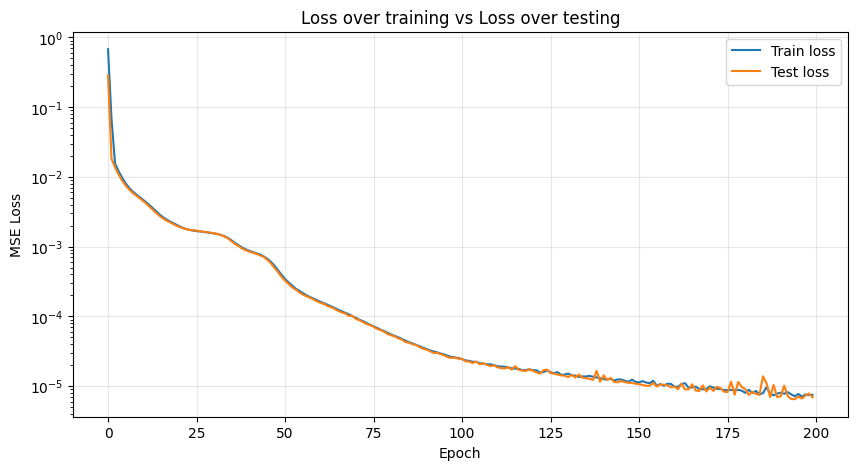

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

tensor([ 2.3101e+00,  2.3091e+00,  2.3061e+00,  2.3010e+00,  2.2940e+00,
         2.2849e+00,  2.2738e+00,  2.2606e+00,  2.2453e+00,  2.2280e+00,
         2.2084e+00,  2.1867e+00,  2.1628e+00,  2.1367e+00,  2.1082e+00,
         2.0774e+00,  2.0441e+00,  2.0084e+00,  1.9701e+00,  1.9292e+00,
         1.8856e+00,  1.8391e+00,  1.7897e+00,  1.7372e+00,  1.6816e+00,
         1.6226e+00,  1.5602e+00,  1.4942e+00,  1.4244e+00,  1.3507e+00,
         1.2730e+00,  1.1912e+00,  1.1053e+00,  1.0156e+00,  9.2249e-01,
         8.2675e-01,  7.2985e-01,  6.3408e-01,  5.4274e-01,  4.6018e-01,
         3.9125e-01,  3.4017e-01,  3.0905e-01,  2.9703e-01,  3.0064e-01,
         3.1513e-01,  3.3583e-01,  3.5895e-01,  3.8178e-01,  4.0256e-01,
         4.2023e-01,  4.3423e-01,  4.4431e-01,  4.5043e-01,  4.5270e-01,
         4.5129e-01,  4.4642e-01,  4.3837e-01,  4.2743e-01,  4.1392e-01,
         3.9816e-01,  3.8053e-01,  3.6138e-01,  3.4110e-01,  3.2008e-01,
         2.9870e-01,  2.7735e-01,  2.5639e-01,  2.3

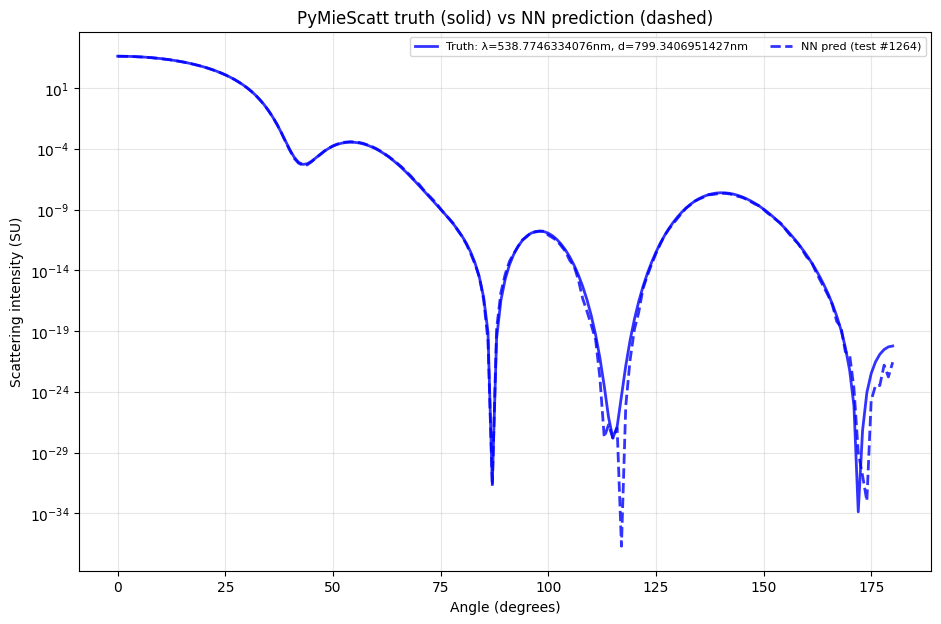

In [57]:
with torch.no_grad():
    test_pred = model(X_test)

# Plot 4 random test cases
plt.figure(figsize=(11, 7))
indices = np.random.choice(len(X_test), 1, replace=False)

print(y_test[indices[0]])
print(test_pred[indices[0]])

# Use different colors for each pair so they're visually distinguishable
colors = ['blue', 'orange', 'green', 'red']

for idx, color in zip(indices, colors):

    # Get the actual physical values (un-normalize)
    norm_w = X_test[idx, 0].item()
    norm_d = X_test[idx, 1].item()
    real_w = norm_w * 100 + 450
    real_d = norm_d * 200 + 700
    
    # Convert log10 back to real brightness values
    true_curve = y_test[idx].numpy() ** 10 # take the log output brightness values and turn them back to their original values
    pred_curve = test_pred[idx].numpy() ** 10 # take the prediction values and turn them back to their original values
    
    # Solid line = truth (PyMieScatt), Dashed line = NN prediction
    plt.plot(true_curve, '-',  color=color, linewidth=2, alpha=0.8,
             label=f"Truth: λ={real_w:.10f}nm, d={real_d:.10f}nm")
    plt.plot(pred_curve, '--', color=color, linewidth=2, alpha=0.8,
             label=f"NN pred (test #{idx})")

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("PyMieScatt truth (solid) vs NN prediction (dashed)")
plt.yscale('log')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

Todo: Still have to try out the tan h compression function between layers. Try to 

Mean squared error (in log space): 9.720327e-06


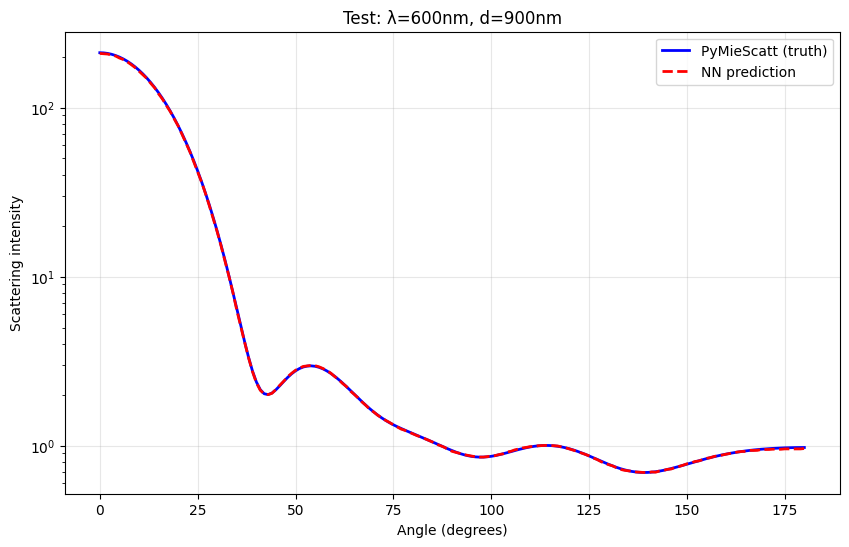

In [69]:
def predict_scattering(wavelength, diameter, n, k):
    """Predict scattering curve for a given wavelength and diameter."""
    # Normalize the inputs the same way we did during training
    norm_wavelength = (wavelength - 450) / 100
    norm_diameter   = (diameter - 700) / 200
    norm_n = (n-1.5)/(1.86-1.5)
    norm_k = (k-0.68)/(0.32)
    
    # Convert to tensor with shape (1, 2) — one example, two features
    input_tensor = torch.FloatTensor([[norm_wavelength, norm_diameter, norm_n, norm_k]])
    
    # Run through the network
    with torch.no_grad():
        log_pred = model(input_tensor)
    
    # Convert from log space back to real brightness
    pred_curve = 10 ** log_pred.numpy().flatten()
    
    return pred_curve


def true_scattering(wavelength, diameter, n, k):
    """Compute the actual PyMieScatt scattering curve."""
    m = complex(n, k) # for any set of parameters
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    return SU


# Pick any wavelength and diameter to test
test_wavelength = 600  # nm
test_diameter = 900    # nm
test_n = 1.7
test_k = 0.8
# Get both predictions
nn_curve = predict_scattering(test_wavelength, test_diameter, test_n, test_k)
true_curve = true_scattering(test_wavelength, test_diameter, test_n, test_k)

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_curve, '-',  color='blue', linewidth=2, label='PyMieScatt (truth)')
plt.plot(nn_curve,   '--', color='red',  linewidth=2, label='NN prediction')
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity")
plt.title(f"Test: λ={test_wavelength}nm, d={test_diameter}nm")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

still understanding this part... work in progress. Doesn't look too accurate though. The neural network is able to predict values within it's trained range very well. As soon as it is given a value that is not within the trained range, it starts to perform more poorly. Values within the training range are predicted very accurately. If the neural network is asked to predict with wavelength and diameter outside of the training range, it is more inaccurate.

This section is used to generate some 2d plots. We'll begin by generating the logspaced diameter testing data.

In [59]:
N_D_SPANNING_DATA = 200
m = complex(1.6, 1.0) # match the m value the NN was trained on
fixed_lambda = 500 # I will be varying diameter not wavelength

# Log-spaced diameter sweep — wider than training range
d_span = np.logspace(np.log10(400), np.log10(900), N_D_SPANNING_DATA)

print("Computing Brightness for Each Diamaeter with PyMieScatt")
truth = np.zeros((N_D_SPANNING_DATA, 181)) # create one dimensional array of 0s

# generate the pyMieScatt curve for each diameter value
for i, d in enumerate(d_span):
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, fixed_lambda, d, minAngle=0, maxAngle=180, angularResolution=1
    )

    # add it in it's spot in the array
    truth[i] = SU
    if i % 50 == 0:
        print(f"  {i}/{N_D_SPANNING_DATA}")

# === Predictions from NN ===
print("Computing NN sweep...")
nn_pred = np.zeros((N_D_SPANNING_DATA, 181))

for i, d in enumerate(d_span):
    norm_w = (fixed_lambda - 450) / 100
    norm_d = (d - 700) / 200
    inp = torch.FloatTensor([[norm_w, norm_d, 1.6, 1.0]])
    with torch.no_grad():
        log_pred = model(inp)
    nn_pred[i] = 10 ** log_pred.numpy().flatten()

print(f"\nDone!")
print(f"Diameter range: {d_span[0]:.0f} to {d_span[-1]:.0f} nm")
print(f"Training was: 700 to 900 nm")


Computing Brightness for Each Diamaeter with PyMieScatt
  0/200
  50/200
  100/200
  150/200
Computing NN sweep...

Done!
Diameter range: 400 to 900 nm
Training was: 700 to 900 nm


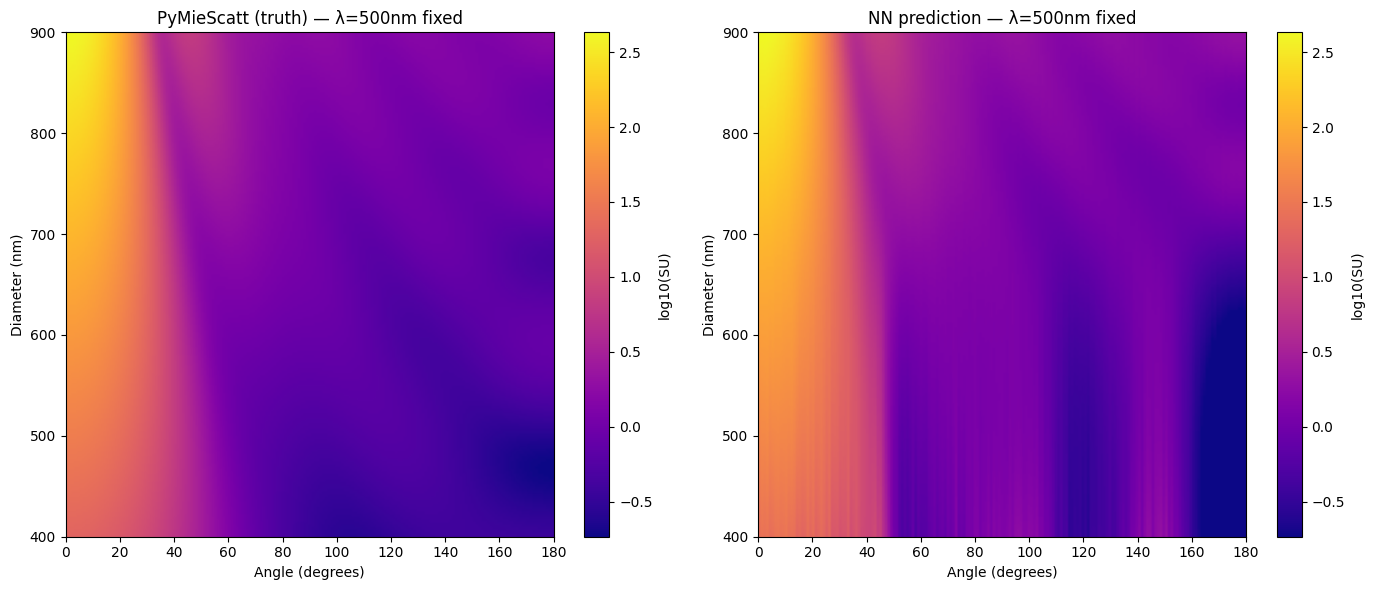

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use the same color scale across both plots so they're directly comparable
vmin = np.log10(truth).min()
vmax = np.log10(truth).max()

# === PyMieScatt truth ===
im1 = axes[0].imshow(
    np.log10(truth),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[0].set_title(f"PyMieScatt (truth) — λ={fixed_lambda}nm fixed")
axes[0].set_xlabel("Angle (degrees)")
axes[0].set_ylabel("Diameter (nm)")
# Show training range boundaries
plt.colorbar(im1, ax=axes[0], label='log10(SU)')

# === NN prediction ===
im2 = axes[1].imshow(
    np.log10(nn_pred),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[1].set_title(f"NN prediction — λ={fixed_lambda}nm fixed")
axes[1].set_xlabel("Angle (degrees)")
axes[1].set_ylabel("Diameter (nm)")
plt.colorbar(im2, ax=axes[1], label='log10(SU)')

plt.tight_layout()
plt.show()